# Post-Training Quantization (PTQ) - FP16 & INT8
Simple & Clean Version

In [1]:
"""
Post-Training Quantization (PTQ) - FP16 & INT8
Simple & Clean Version
"""
import os, time, json
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.models import Model
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# ============================================================================
# SETUP
# ============================================================================
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU'))} device(s)\n")

TensorFlow: 2.21.0
GPU: 0 device(s)



## CUSTOM LAYER

In [2]:
# ============================================================================
# CUSTOM LAYER
# ============================================================================
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Reshape, Multiply
        channels = input_shape[-1]
        self.gap = GlobalAveragePooling2D()
        self.dense1 = Dense(max(1, channels // self.ratio), activation="relu")
        self.dense2 = Dense(channels, activation="sigmoid")
        self.reshape = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        from tensorflow.keras.layers import Multiply
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

CUSTOM_OBJECTS = {"ChannelAttention": ChannelAttention}

## HELPERS

In [3]:
# ============================================================================
# HELPERS
# ============================================================================
def get_size_kb(path):
    return os.path.getsize(path) / 1024 if os.path.exists(path) else 0

class TFLiteExtractor:
    """Wrapper for TFLite interpreter to mimic Keras model interface"""
    def __init__(self, interpreter):
        self.interpreter = interpreter
        self.input_details = interpreter.get_input_details()
        self.output_details = interpreter.get_output_details()
    
    def predict(self, X, verbose=0, batch_size=None):
        """Extract features for all images"""
        feats = []
        for img in X:
            self.interpreter.set_tensor(self.input_details[0]['index'], img[np.newaxis, ...])
            self.interpreter.invoke()
            feat = self.interpreter.get_tensor(self.output_details[0]['index'])[0]
            feats.append(feat)
        return np.array(feats)


PREDICT_BATCH_SIZE = 16

def predict_features(extractor, X):
    try:
        return extractor.predict(X, verbose=0, batch_size=PREDICT_BATCH_SIZE)
    except TypeError:
        return extractor.predict(X, verbose=0)
def evaluate_model(extractor, svm, scaler, X, y_true, class_names, label, warmup=True):
    """Evaluate and return metrics"""
    # Feature extraction (with timing)
    if warmup:
        warmup_n = min(2, len(X))
        if warmup_n > 0:
            _ = predict_features(extractor, X[:warmup_n])
    t0 = time.perf_counter()
    feats = predict_features(extractor, X)
    feat_time = time.perf_counter() - t0
    
    # SVM prediction (with timing)
    t0 = time.perf_counter()
    feats_scaled = scaler.transform(feats)
    y_pred = svm.predict(feats_scaled)
    y_proba = svm.predict_proba(feats_scaled)
    inf_time = time.perf_counter() - t0
    
    # Metrics
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    sensitivity = report['macro avg']['recall']
    precision = report['macro avg']['precision']
    f1 = report['macro avg']['f1-score']
    
    # Specificity
    specs = []
    for i in range(len(class_names)):
        tn = cm.sum() - cm[i,:].sum() - cm[:,i].sum() + cm[i,i]
        fp = cm[:,i].sum() - cm[i,i]
        specs.append(tn/(tn+fp) if (tn+fp)>0 else 0)
    specificity = np.mean(specs)
    
    # AUC
    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    auc = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
    
    return {
        'label': label,
        'accuracy': acc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'auc': auc,
        'cm': cm,
        'feat_time': feat_time,
        'inf_time': inf_time
    }

## LOAD DATA

In [4]:
# ============================================================================
# LOAD DATA
# ============================================================================
print("="*70)
print("LOADING DATASET")
print("="*70)

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()

dataset_base_path = os.path.join(os.path.dirname(SCRIPT_DIR), "dataset_processed2")
if not os.path.exists(dataset_base_path):
    dataset_base_path = "../dataset_processed2"
if not os.path.exists(dataset_base_path):
    dataset_base_path = "dataset_processed2"

img_size = 224
categories = ["Bengin cases", "Malignant cases", "Normal cases"]
class_names = ["Bengin", "Malignant", "Normal"]
num_classes = len(categories)

def load_split_data(split_path, categories):
    X, y = [], []
    for class_idx, cat in enumerate(categories):
        cat_path = os.path.join(split_path, cat)
        if not os.path.isdir(cat_path):
            continue
        for fn in sorted(os.listdir(cat_path)):
            if not fn.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = cv2.imread(os.path.join(cat_path, fn))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0
            X.append(img)
            y.append(class_idx)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading dataset...")
X_train, y_train = load_split_data(os.path.join(dataset_base_path, "train"), categories)
X_valid, y_valid = load_split_data(os.path.join(dataset_base_path, "valid"), categories)
X_test, y_test = load_split_data(os.path.join(dataset_base_path, "test"), categories)

print(f"Train: {X_train.shape}")
print(f"Valid: {X_valid.shape}")
print(f"Test:  {X_test.shape}")

print("\nClass distribution (train):")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    pct = count / len(y_train) * 100
    print(f"  {name:<12}: {count:4d} ({pct:5.2f}%)")
print()

LOADING DATASET
Loading dataset...
Train: (737, 224, 224, 3)
Valid: (158, 224, 224, 3)
Test:  (159, 224, 224, 3)

Class distribution (train):
  Bengin      :   71 ( 9.63%)
  Malignant   :  383 (51.97%)
  Normal      :  283 (38.40%)



## LOAD BASELINE MODEL

In [5]:
# ============================================================================
# LOAD BASELINE MODEL
# ============================================================================
print("="*70)
print("LOADING BASELINE MODEL")
print("="*70)

ORIG_FOLDER = os.path.join(SCRIPT_DIR, "saved_models_original")

if not os.path.isdir(ORIG_FOLDER):
    print(f"❌ Folder '{ORIG_FOLDER}' tidak ditemukan.")
    print(f"   Jalankan training.py terlebih dahulu atau update ORIG_FOLDER.")
else:
    cnn_path = os.path.join(ORIG_FOLDER, "cnn_attention_model.keras")
    extractor_path = os.path.join(ORIG_FOLDER, "feature_extractor.keras")
    svm_path = os.path.join(ORIG_FOLDER, "svm_classifier.pkl")
    scaler_path = os.path.join(ORIG_FOLDER, "feature_scaler.pkl")

    print(f"Loading artifacts from {ORIG_FOLDER}/...")
    model_baseline = tf.keras.models.load_model(cnn_path, custom_objects=CUSTOM_OBJECTS)
    extractor_baseline = tf.keras.models.load_model(extractor_path, custom_objects=CUSTOM_OBJECTS)
    svm_baseline = joblib.load(svm_path)
    scaler_baseline = joblib.load(scaler_path)

    print(f"✅ Models loaded")
    print(f"   CNN params: {model_baseline.count_params():,}")
    print(f"   Extractor params: {extractor_baseline.count_params():,}")
    print(f"   Pipeline size: {get_size_kb(extractor_path) + get_size_kb(svm_path) + get_size_kb(scaler_path):.2f} KB\n")

    # Evaluate baseline
    print("Evaluating baseline...")
    metrics_baseline = evaluate_model(extractor_baseline, svm_baseline, scaler_baseline,
                                      X_test, y_test, class_names, "Baseline (FP32)")
    print(f"✅ Baseline accuracy: {metrics_baseline['accuracy']:.4f}\n")

LOADING BASELINE MODEL
Loading artifacts from d:\bintang\skripsi 0606\saved_models_original/...

✅ Models loaded
   CNN params: 1,627,343
   Extractor params: 1,627,292
   Pipeline size: 6454.70 KB

Evaluating baseline...
✅ Baseline accuracy: 0.9937



## FP16 QUANTIZATION

In [6]:
# ============================================================================
# FP16 QUANTIZATION
# ============================================================================
print("="*70)
print("FP16 QUANTIZATION")
print("="*70)

# Convert to TFLite FP16
print("Converting to FP16 TFLite...")
converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(extractor_baseline)
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]

tflite_fp16 = converter_fp16.convert()
fp16_path = "artifacts/extractor_fp16.tflite"
os.makedirs("artifacts", exist_ok=True)
with open(fp16_path, 'wb') as f:
    f.write(tflite_fp16)

size_fp16 = len(tflite_fp16) / 1024
print(f"✅ FP16 saved: {size_fp16:.2f} KB ({get_size_kb(cnn_path)/size_fp16:.2f}x compression)\n")

# FP16 feature extraction
print("Extracting features with FP16...")
interpreter_fp16 = tf.lite.Interpreter(model_path=fp16_path)
interpreter_fp16.allocate_tensors()
extractor_fp16 = TFLiteExtractor(interpreter_fp16)

X_train_fp16 = extractor_fp16.predict(X_train)
X_valid_fp16 = extractor_fp16.predict(X_valid)
X_test_fp16 = extractor_fp16.predict(X_test)

# Train SVM on FP16 features
print("Training SVM on FP16 features...")
scaler_fp16 = StandardScaler()
X_combined_fp16 = np.vstack([X_train_fp16, X_valid_fp16])
y_combined = np.concatenate([y_train, y_valid])
X_combined_scaled = scaler_fp16.fit_transform(X_combined_fp16)

# Use same hardcoded SVM parameters as training.ipynb
svm_fp16 = SVC(kernel='rbf', C=0.1, gamma='scale', probability=True, random_state=42, class_weight="balanced")
svm_fp16.fit(X_combined_scaled, y_combined)

# Evaluate FP16
print("Evaluating FP16...")
metrics_fp16 = evaluate_model(extractor_fp16, svm_fp16, scaler_fp16, 
                              X_test, y_test, class_names, "FP16")
print(f"✅ FP16 accuracy: {metrics_fp16['accuracy']:.4f}\n")

FP16 QUANTIZATION
Converting to FP16 TFLite...
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp1y748uog\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp1y748uog\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmp1y748uog'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  1842043494192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043497360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842042943648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043664016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043662960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043651520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043596016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043595488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043660496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043663136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842

d:\bintang\skripsi 0606\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Training SVM on FP16 features...
Evaluating FP16...
✅ FP16 accuracy: 0.9937



## INT8 QUANTIZATION

In [7]:
# ============================================================================
# INT8 QUANTIZATION
# ============================================================================
print("="*70)
print("INT8 QUANTIZATION")
print("="*70)

# Convert to TFLite INT8
print("Converting to INT8 TFLite...")

def rep_dataset():
    for i in range(100):
        yield [X_train[i:i+1]]

converter_int8 = tf.lite.TFLiteConverter.from_keras_model(extractor_baseline)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = rep_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter_int8.inference_input_type = tf.float32
converter_int8.inference_output_type = tf.float32

tflite_int8 = converter_int8.convert()
int8_path = "artifacts/extractor_int8.tflite"
with open(int8_path, 'wb') as f:
    f.write(tflite_int8)

size_int8 = len(tflite_int8) / 1024
print(f"✅ INT8 saved: {size_int8:.2f} KB ({get_size_kb(cnn_path)/size_int8:.2f}x compression)\n")

# INT8 feature extraction
print("Extracting features with INT8...")
interpreter_int8 = tf.lite.Interpreter(model_path=int8_path)
interpreter_int8.allocate_tensors()
extractor_int8 = TFLiteExtractor(interpreter_int8)

X_train_int8 = extractor_int8.predict(X_train)
X_valid_int8 = extractor_int8.predict(X_valid)
X_test_int8 = extractor_int8.predict(X_test)

# Train SVM on INT8 features
print("Training SVM on INT8 features...")
scaler_int8 = StandardScaler()
X_combined_int8 = np.vstack([X_train_int8, X_valid_int8])
X_combined_scaled = scaler_int8.fit_transform(X_combined_int8)

# Use same hardcoded SVM parameters as training.ipynb
svm_int8 = SVC(kernel='rbf', C=0.1, gamma='scale', probability=True, random_state=42, class_weight="balanced")
svm_int8.fit(X_combined_scaled, y_combined)

# Evaluate INT8
print("Evaluating INT8...")
metrics_int8 = evaluate_model(extractor_int8, svm_int8, scaler_int8,
                              X_test, y_test, class_names, "INT8")
print(f"✅ INT8 accuracy: {metrics_int8['accuracy']:.4f}\n")

INT8 QUANTIZATION
Converting to INT8 TFLite...
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpdoyew7cn\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpdoyew7cn\assets


Saved artifact at 'C:\Users\User\AppData\Local\Temp\tmpdoyew7cn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  1842043494192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043497360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842042943648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043664016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043662960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043651520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043596016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043595488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043660496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842043663136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1842

d:\bintang\skripsi 0606\.venv\lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


✅ INT8 saved: 1604.92 KB (11.93x compression)

Extracting features with INT8...


d:\bintang\skripsi 0606\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Training SVM on INT8 features...
Evaluating INT8...
✅ INT8 accuracy: 0.9937



## SAVE MODELS

In [8]:
# ============================================================================
# SAVE MODELS
# ============================================================================
print("="*70)
print("SAVING MODELS")
print("="*70)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
save_folder = f"saved_models_ptq_{timestamp}"
os.makedirs(save_folder, exist_ok=True)

# Save TFLite
import shutil
shutil.copy2(fp16_path, os.path.join(save_folder, "extractor_fp16.tflite"))
shutil.copy2(int8_path, os.path.join(save_folder, "extractor_int8.tflite"))

# Save SVM & Scalers
joblib.dump(svm_fp16, os.path.join(save_folder, "svm_fp16.pkl"))
joblib.dump(scaler_fp16, os.path.join(save_folder, "scaler_fp16.pkl"))
joblib.dump(svm_int8, os.path.join(save_folder, "svm_int8.pkl"))
joblib.dump(scaler_int8, os.path.join(save_folder, "scaler_int8.pkl"))

# Save baseline reference
model_baseline.save(os.path.join(save_folder, "baseline.keras"))
joblib.dump(svm_baseline, os.path.join(save_folder, "svm_baseline.pkl"))
joblib.dump(scaler_baseline, os.path.join(save_folder, "scaler_baseline.pkl"))

print(f"✅ Saved to: {save_folder}/\n")

SAVING MODELS
✅ Saved to: saved_models_ptq_20260608_200513/



## COMPARISON TABLE

In [9]:
# ============================================================================
# COMPARISON TABLE
# ============================================================================
print("="*70)
print("COMPARISON TABLE")
print("="*70)
print("Note: Model Size = feature extractor/TFLite + SVM (.pkl) + Scaler (.pkl)")

results = [metrics_baseline, metrics_fp16, metrics_int8]

# Size mengikuti aturan notebook lain: ukuran pipeline inferensi lengkap.
# Baseline memakai feature extractor asli, bukan full CNN training model.
size_baseline = (
    get_size_kb(extractor_path)
    + get_size_kb(svm_path)
    + get_size_kb(scaler_path)
)
size_fp16_pipeline = (
    get_size_kb(os.path.join(save_folder, "extractor_fp16.tflite"))
    + get_size_kb(os.path.join(save_folder, "svm_fp16.pkl"))
    + get_size_kb(os.path.join(save_folder, "scaler_fp16.pkl"))
)
size_int8_pipeline = (
    get_size_kb(os.path.join(save_folder, "extractor_int8.tflite"))
    + get_size_kb(os.path.join(save_folder, "svm_int8.pkl"))
    + get_size_kb(os.path.join(save_folder, "scaler_int8.pkl"))
)

sizes = [size_baseline, size_fp16_pipeline, size_int8_pipeline]

# Build table
comp_data = []
for i, m in enumerate(results):
    comp_data.append({
        "Model": m['label'],
        "Size (KB)": f"{sizes[i]:.2f}",
        "Compression": f"{sizes[0]/sizes[i]:.2f}x",
        "Accuracy": f"{m['accuracy']:.4f}",
        "Sensitivity": f"{m['sensitivity']:.4f}",
        "Specificity": f"{m['specificity']:.4f}",
        "Precision": f"{m['precision']:.4f}",
        "F1-Score": f"{m['f1']:.4f}",
        "AUC": f"{m['auc']:.4f}",
        "Feat Ext (ms)": f"{m['feat_time']*1000:.2f}",
        "SVM Inf (ms)": f"{m['inf_time']*1000:.2f}",
        "Total (ms)": f"{(m['feat_time']+m['inf_time'])*1000:.2f}"
    })

df_comp = pd.DataFrame(comp_data)
print()
print(df_comp.to_string(index=False))

# Save CSV/JSON
comparison_csv_path = os.path.join(save_folder, "comparison.csv")
comparison_json_path = os.path.join(save_folder, "comparison_table.json")
df_comp.to_csv(comparison_csv_path, index=False)
df_comp.to_json(comparison_json_path, orient="records", indent=2)

summary = {}
for i, m in enumerate(results):
    key = m['label'].lower().replace(' ', '_').replace('(', '').replace(')', '')
    summary[key] = {
        'accuracy': float(m['accuracy']),
        'sensitivity': float(m['sensitivity']),
        'specificity': float(m['specificity']),
        'precision': float(m['precision']),
        'f1': float(m['f1']),
        'auc': float(m['auc']),
        'size_kb': float(sizes[i]),
        'feat_time_ms': float(m['feat_time'] * 1000),
        'inf_time_ms': float(m['inf_time'] * 1000),
        'total_time_ms': float((m['feat_time'] + m['inf_time']) * 1000),
        'degradation_pct': float((results[0]['accuracy'] - m['accuracy']) / results[0]['accuracy'] * 100) if i > 0 else 0.0,
        'speedup': float((results[0]['feat_time'] + results[0]['inf_time']) / (m['feat_time'] + m['inf_time']))
    }

summary_path = os.path.join(save_folder, "summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)


COMPARISON TABLE
Note: Model Size = feature extractor/TFLite + SVM (.pkl) + Scaler (.pkl)

          Model Size (KB) Compression Accuracy Sensitivity Specificity Precision F1-Score    AUC Feat Ext (ms) SVM Inf (ms) Total (ms)
Baseline (FP32)   6454.70       1.00x   0.9937      0.9945      0.9977    0.9804   0.9871 0.9994       1080.61         5.02    1085.64
           FP16   3237.15       1.99x   0.9937      0.9945      0.9977    0.9804   0.9871 0.9994       1456.17         4.62    1460.79
           INT8   1651.98       3.91x   0.9937      0.9945      0.9977    0.9804   0.9871 0.9994        739.46         4.68     744.14


## VISUALIZATIONS


CREATING VISUALIZATIONS
✅ Comparison plots saved


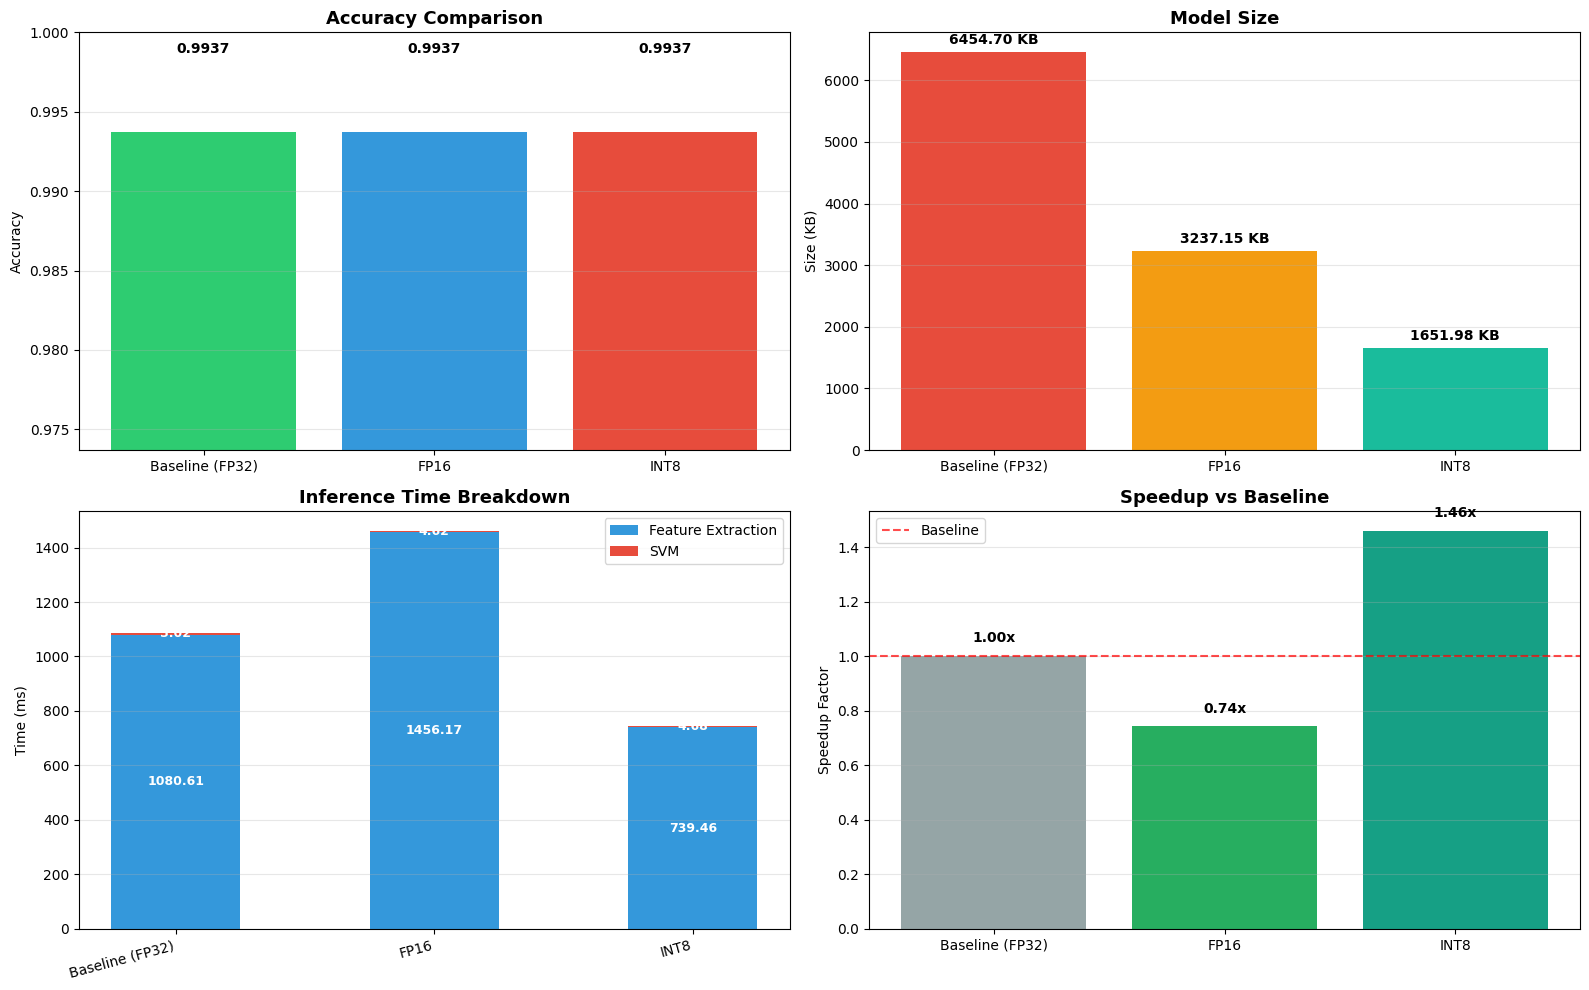

✅ Confusion matrices saved


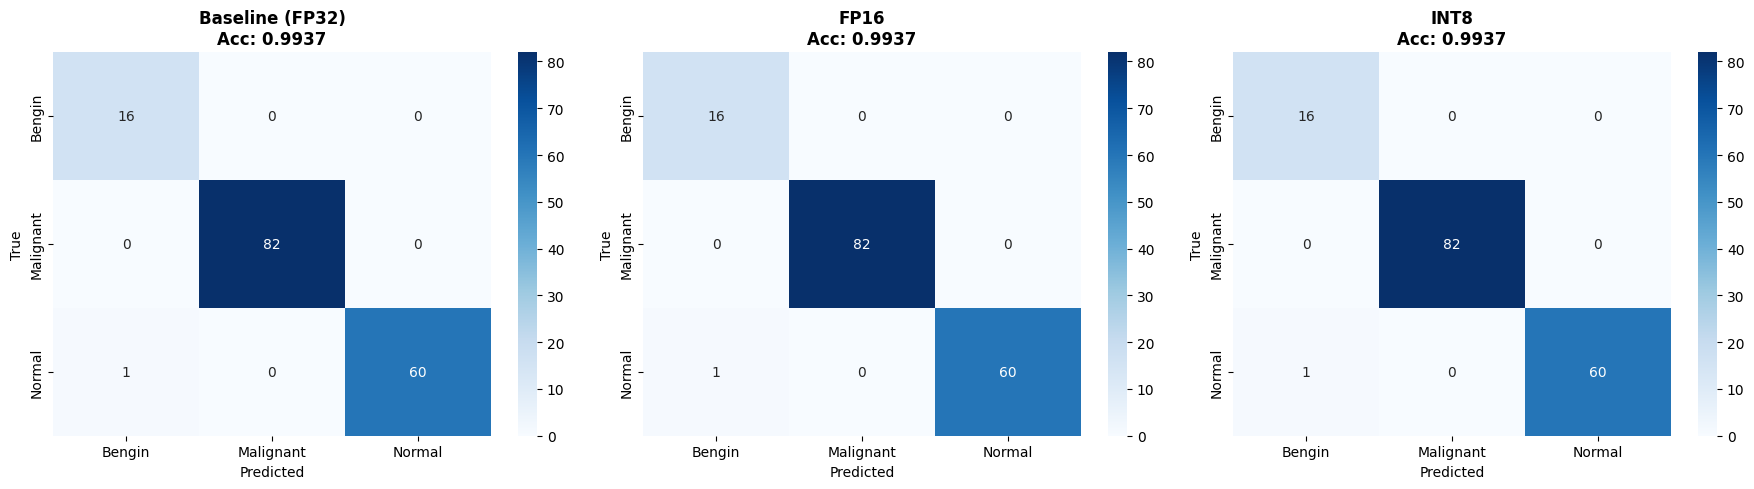

In [10]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================
print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Accuracy
acc_vals = [float(d['Accuracy']) for d in comp_data]
bars = axes[0,0].bar([d['Model'] for d in comp_data], acc_vals, 
                     color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0,0].set_ylim(min(acc_vals)-0.02, 1.0)
axes[0,0].set_title("Accuracy Comparison", fontsize=13, fontweight='bold')
axes[0,0].set_ylabel("Accuracy")
axes[0,0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, acc_vals):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                  f'{val:.4f}', ha='center', fontweight='bold')

# 2. Model Size
size_vals = [float(d['Size (KB)']) for d in comp_data]
bars = axes[0,1].bar([d['Model'] for d in comp_data], size_vals,
                     color=['#e74c3c', '#f39c12', '#1abc9c'])
axes[0,1].set_title("Model Size", fontsize=13, fontweight='bold')
axes[0,1].set_ylabel("Size (KB)")
axes[0,1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, size_vals):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(size_vals)*0.02,
                  f'{val:.2f} KB', ha='center', fontweight='bold')

# 3. Time Breakdown (Stacked)
feat_times = [m['feat_time']*1000 for m in results]
svm_times = [m['inf_time']*1000 for m in results]
models = [d['Model'] for d in comp_data]

x = np.arange(len(models))
bars1 = axes[1,0].bar(x, feat_times, 0.5, label='Feature Extraction', color='#3498db')
bars2 = axes[1,0].bar(x, svm_times, 0.5, bottom=feat_times, label='SVM', color='#e74c3c')
axes[1,0].set_ylabel('Time (ms)')
axes[1,0].set_title('Inference Time Breakdown', fontsize=13, fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(models, rotation=15, ha='right')
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# Add labels
for i, (f, s) in enumerate(zip(feat_times, svm_times)):
    axes[1,0].text(i, f/2, f'{f:.2f}', ha='center', va='center', 
                  color='white', fontweight='bold', fontsize=9)
    axes[1,0].text(i, f+s/2, f'{s:.2f}', ha='center', va='center',
                  color='white', fontweight='bold', fontsize=9)

# 4. Speedup
total_times = [f+s for f,s in zip(feat_times, svm_times)]
speedups = [total_times[0]/t for t in total_times]
bars = axes[1,1].bar(models, speedups, color=['#95a5a6', '#27ae60', '#16a085'])
axes[1,1].set_title('Speedup vs Baseline', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Speedup Factor')
axes[1,1].axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Baseline')
axes[1,1].legend()
axes[1,1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, speedups):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                  f'{val:.2f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_folder, "comparison_plots.png"), dpi=150, bbox_inches='tight')
print(f"✅ Comparison plots saved")
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, m, title in zip(axes, results, [m['label'] for m in results]):
    sns.heatmap(m['cm'], annot=True, fmt='d', cmap='Blues', 
               xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f"{title}\nAcc: {m['accuracy']:.4f}", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(save_folder, "confusion_matrices.png"), dpi=150, bbox_inches='tight')
print(f"✅ Confusion matrices saved")
plt.show()

## FINAL SUMMARY

In [11]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================
print()
print("="*70)
print("QUANTIZATION COMPLETE!")
print("="*70)
print()
print(f"Saved to: {save_folder}/")
print()
print("Summary:")
print("Model Size = feature extractor/TFLite + SVM (.pkl) + Scaler (.pkl)")
for i, m in enumerate(results):
    deg = (results[0]['accuracy'] - m['accuracy']) / results[0]['accuracy'] * 100
    speedup = (results[0]['feat_time'] + results[0]['inf_time']) / (m['feat_time'] + m['inf_time'])
    print()
    print(f"{m['label']}:")
    print(f"  Accuracy: {m['accuracy']:.4f} ({deg:+.2f}% degradation)")
    print(f"  Size: {sizes[i]:.2f} KB ({sizes[0]/sizes[i]:.2f}x compression)")
    print(f"  Time: {(m['feat_time']+m['inf_time'])*1000:.2f} ms ({speedup:.2f}x speedup)")

print()
print("="*70)
print("Files saved:")
print(f"  - {save_folder}/extractor_fp16.tflite")
print(f"  - {save_folder}/extractor_int8.tflite")
print(f"  - {save_folder}/svm_fp16.pkl, scaler_fp16.pkl")
print(f"  - {save_folder}/svm_int8.pkl, scaler_int8.pkl")
print(f"  - {save_folder}/baseline.keras")
print(f"  - {save_folder}/comparison.csv")
print(f"  - {save_folder}/summary.json")
print(f"  - {save_folder}/comparison_plots.png")
print(f"  - {save_folder}/confusion_matrices.png")
print("="*70)



QUANTIZATION COMPLETE!

Saved to: saved_models_ptq_20260608_200513/

Summary:
Model Size = feature extractor/TFLite + SVM (.pkl) + Scaler (.pkl)

Baseline (FP32):
  Accuracy: 0.9937 (+0.00% degradation)
  Size: 6454.70 KB (1.00x compression)
  Time: 1085.64 ms (1.00x speedup)

FP16:
  Accuracy: 0.9937 (+0.00% degradation)
  Size: 3237.15 KB (1.99x compression)
  Time: 1460.79 ms (0.74x speedup)

INT8:
  Accuracy: 0.9937 (+0.00% degradation)
  Size: 1651.98 KB (3.91x compression)
  Time: 744.14 ms (1.46x speedup)

Files saved:
  - saved_models_ptq_20260608_200513/extractor_fp16.tflite
  - saved_models_ptq_20260608_200513/extractor_int8.tflite
  - saved_models_ptq_20260608_200513/svm_fp16.pkl, scaler_fp16.pkl
  - saved_models_ptq_20260608_200513/svm_int8.pkl, scaler_int8.pkl
  - saved_models_ptq_20260608_200513/baseline.keras
  - saved_models_ptq_20260608_200513/comparison.csv
  - saved_models_ptq_20260608_200513/summary.json
  - saved_models_ptq_20260608_200513/comparison_plots.png
  -